<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Deep_learning_Arabic_Readability_Classification_AraBERTv2_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arabic Readability Classification on BAREC
## Deep Learning: AraBERTv2 with Softmax and CORAL Ordinal Classification

This notebook keeps the official BAREC train/dev/test document-level splits, merges the original levels 4 and 5 into one class, and compares two fine-tuned AraBERTv2 models:

1. **Softmax baseline**: treats the four levels as unrelated classes.
2. **CORAL ordinal model (recommended)**: uses the natural order 1 < 2 < 3 < 4.

The final comparison uses Accuracy, Macro-F1, Quadratic Weighted Kappa (QWK), Mean Absolute Error (MAE), and within-one-level accuracy.


# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [1]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [2]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [3]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [4]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [5]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")

# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [6]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [7]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [8]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0
Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level and 5-level readability classes to understand whether the dataset is balanced or imbalanced.

In [9]:
# Distribution for Readability Level 19
level_19_stats = (
    filtered_full_df["Readability_Level_19"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_19_stats["Percentage"] = (
    level_19_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 19 ===")
display(level_19_stats)


# Distribution for Readability Level 5
level_5_stats = (
    filtered_full_df["Readability_Level_5"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

level_5_stats["Percentage"] = (
    level_5_stats["Count"] / len(filtered_full_df) * 100
).round(2)

print("=== Readability Level 5 ===")
display(level_5_stats)

=== Readability Level 19 ===


,Count,Percentage
Readability_Level_19,,
1,409,0.59
2,437,0.63
3,1462,2.11
4,751,1.08
5,3443,4.96
6,1534,2.21
7,5438,7.83
8,5683,8.18
9,2023,2.91


=== Readability Level 5 ===


,Count,Percentage
Readability_Level_5,,
1,13474,19.40
2,22383,32.23
3,18510,26.66
4,13234,19.06
5,1840,2.65


In [10]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


In [11]:
filtered_full_df["Readability_Level_5"].value_counts().sort_index()

,count
Readability_Level_5,
1,13474
2,22383
3,18510
4,13234
5,1840


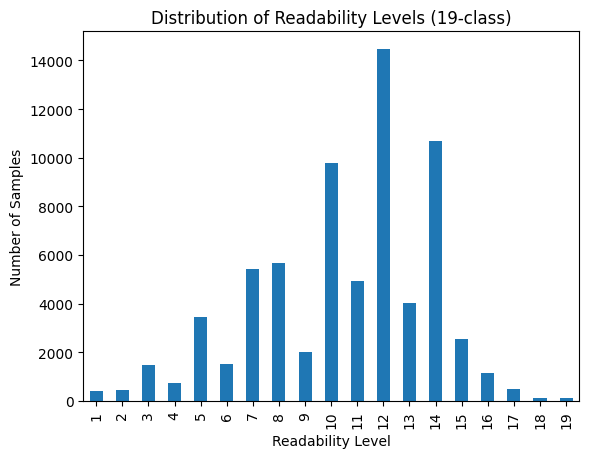

In [12]:
import matplotlib.pyplot as plt

full_df["Readability_Level_19"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

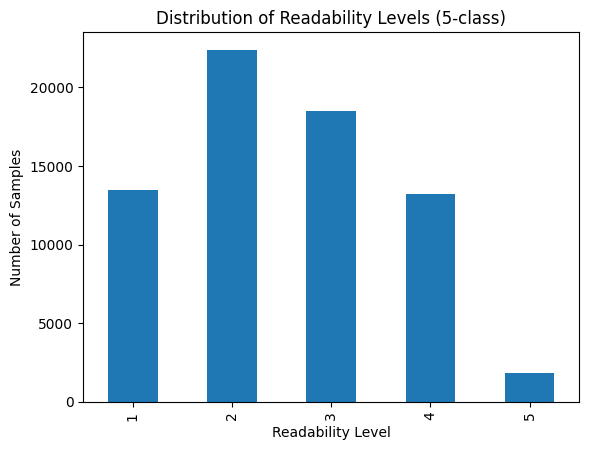

In [13]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (5-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 and 5 readability levels. Some classes contain a significantly higher number of samples, while higher levels have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.

##Handling Class Label Inbalance

### Step 1: Merge Readability Classes 4 and 5

The original `Readability_Level_5` contains five readability classes.

To reduce the class imbalance, Classes 4 and 5 will be merged into a single class. All samples originally labeled as Class 5 will be relabeled as Class 4.

As a result, the dataset will contain four readability classes: 1, 2, 3, and 4.

The original Class 5 label will no longer exist in the dataset.

In [14]:
# Create separate copies of the original BAREC splits
train_4 = filtered_train_df.copy()
val_4 = filtered_dev_df.copy()
test_4 = filtered_test_df.copy()

# Merge original Class 5 into Class 4 within each split
train_4["Readability_Level_5"] = train_4["Readability_Level_5"].replace(5, 4)
val_4["Readability_Level_5"] = val_4["Readability_Level_5"].replace(5, 4)
test_4["Readability_Level_5"] = test_4["Readability_Level_5"].replace(5, 4)

# Rename the target column
train_4 = train_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
val_4 = val_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})
test_4 = test_4.rename(columns={"Readability_Level_5": "Readability_Level_4"})

# Display the original BAREC split sizes
print("=== Four-Class Dataset Sizes ===")
print(f"Train: {len(train_4)}")
print(f"Validation: {len(val_4)}")
print(f"Test: {len(test_4)}")

=== Four-Class Dataset Sizes ===
Train: 54845
Validation: 7310
Test: 7286


### Step 2: Verify the Four-Class Class Distribution

The class distribution is examined separately for the training, validation, and test sets after merging Classes 4 and 5. This step verifies that the four-class target contains only Classes 1, 2, 3, and 4.

In [15]:
# Check the four-class distribution in each split

print("=== Train Class Distribution ===")
print(train_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Validation Class Distribution ===")
print(val_4["Readability_Level_4"].value_counts().sort_index())

print("\n=== Test Class Distribution ===")
print(test_4["Readability_Level_4"].value_counts().sort_index())

=== Train Class Distribution ===
Readability_Level_4
1    10396
2    17908
3    14570
4    11971
Name: count, dtype: int64

=== Validation Class Distribution ===
Readability_Level_4
1    1679
2    2270
3    1840
4    1521
Name: count, dtype: int64

=== Test Class Distribution ===
Readability_Level_4
1    1399
2    2205
3    2100
4    1582
Name: count, dtype: int64


### Step 3: Calculate Class Percentages

The percentage of each readability class is calculated for the training, validation, and test sets. This provides a clearer view of the class distribution and the remaining class imbalance after merging Classes 4 and 5.

In [16]:
# Calculate class percentages for each split

for name, df in [
    ("Train", train_4),
    ("Validation", val_4),
    ("Test", test_4)
]:
    percentages = (
        df["Readability_Level_4"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\n=== {name} Class Percentages ===")
    print(percentages.round(2))


=== Train Class Percentages ===
Readability_Level_4
1    18.96
2    32.65
3    26.57
4    21.83
Name: proportion, dtype: float64

=== Validation Class Percentages ===
Readability_Level_4
1    22.97
2    31.05
3    25.17
4    20.81
Name: proportion, dtype: float64

=== Test Class Percentages ===
Readability_Level_4
1    19.20
2    30.26
3    28.82
4    21.71
Name: proportion, dtype: float64


# Deep Learning Experiment

## Why AraBERTv2 + CORAL?

The target is not an ordinary nominal category: predicting Level 3 for a Level 4 sentence is less severe than predicting Level 1. Therefore, the recommended model combines:

- **AraBERTv2** for contextual Arabic sentence representations.
- **CORAL ordinal loss** to learn the ordered boundaries between the four levels.

A standard AraBERTv2 Softmax classifier is trained as a baseline under the same data and evaluation protocol. This makes the comparison attributable to the classification head rather than to a different encoder.

> Important: model selection is based on validation QWK. The test split is used once for final reporting.


In [17]:
# Install the libraries required for transformer fine-tuning.
# In Google Colab, select a GPU runtime before running this cell.
!pip -q install -U transformers datasets accelerate scikit-learn seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.5 MB/s eta 0:00:00


In [18]:
import os
import random
import inspect
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from transformers import (
    AutoConfig,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.modeling_outputs import SequenceClassifierOutput

SEED = 42
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
TEXT_COLUMN = "Word"
LABEL_COLUMN = "Readability_Level_4"
NUM_LABELS = 4
MAX_LENGTH = 128

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 1. Final data preparation

The earlier duplicate-checking cell reported duplicates but did not assign the cleaned result back to the split dataframes. The next cell fixes this. Duplicates are removed **inside each official split**, without concatenating and randomly re-splitting the corpus, so the official document-level separation remains intact.


In [19]:
def prepare_split(df):
    prepared = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
    prepared[TEXT_COLUMN] = prepared[TEXT_COLUMN].astype(str).str.strip()
    prepared = prepared[prepared[TEXT_COLUMN].ne("")]
    prepared = prepared.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN])
    prepared = prepared.drop_duplicates(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)
    # Convert human-readable labels 1..4 to model labels 0..3.
    prepared["labels"] = prepared[LABEL_COLUMN].astype(int) - 1
    return prepared[[TEXT_COLUMN, "labels"]]

train_dl = prepare_split(train_4)
val_dl = prepare_split(val_4)
test_dl = prepare_split(test_4)

for split_name, split_df in [("Train", train_dl), ("Validation", val_dl), ("Test", test_dl)]:
    print(f"{split_name}: {len(split_df):,} examples")
    print(split_df["labels"].value_counts().sort_index().rename(index=lambda x: x + 1), "\n")

assert set(train_dl["labels"].unique()).issubset(set(range(NUM_LABELS)))
assert set(val_dl["labels"].unique()).issubset(set(range(NUM_LABELS)))
assert set(test_dl["labels"].unique()).issubset(set(range(NUM_LABELS)))


Train: 51,853 examples
labels
1     8602
2    17319
3    14077
4    11855
Name: count, dtype: int64 

Validation: 7,094 examples
labels
1    1545
2    2224
3    1814
4    1511
Name: count, dtype: int64 

Test: 7,030 examples
labels
1    1254
2    2162
3    2043
4    1571
Name: count, dtype: int64 



In [20]:
# Check exact text overlap across official splits. We report it rather than silently
# changing the official BAREC evaluation protocol.
train_texts = set(train_dl[TEXT_COLUMN])
val_texts = set(val_dl[TEXT_COLUMN])
test_texts = set(test_dl[TEXT_COLUMN])

print("Train/validation exact-text overlap:", len(train_texts & val_texts))
print("Train/test exact-text overlap:", len(train_texts & test_texts))
print("Validation/test exact-text overlap:", len(val_texts & test_texts))


Train/validation exact-text overlap: 212
Train/test exact-text overlap: 279
Validation/test exact-text overlap: 85


## 2. Tokenization

AraBERT has its own subword tokenizer. We do not apply stemming, stop-word removal, TF-IDF, or aggressive normalization because these can remove readability signals and do not match the pretrained model input.


In [21]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df):
    ds = Dataset.from_pandas(df, preserve_index=False)
    return ds.map(
        lambda batch: tokenizer(
            batch[TEXT_COLUMN],
            truncation=True,
            max_length=MAX_LENGTH,
        ),
        batched=True,
        remove_columns=[TEXT_COLUMN],
    )

train_ds = to_hf_dataset(train_dl)
val_ds = to_hf_dataset(val_dl)
test_ds = to_hf_dataset(test_dl)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

lengths = [len(tokenizer(text, truncation=False)["input_ids"]) for text in train_dl[TEXT_COLUMN]]
print(pd.Series(lengths).describe(percentiles=[0.90, 0.95, 0.99]))
print(f"Percentage longer than MAX_LENGTH={MAX_LENGTH}: {np.mean(np.array(lengths) > MAX_LENGTH) * 100:.2f}%")


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/51853 [00:00<?, ? examples/s]

Map:   0%|          | 0/7094 [00:00<?, ? examples/s]

Map:   0%|          | 0/7030 [00:00<?, ? examples/s]

count    51853.000000
mean        20.193393
std         14.035863
min          3.000000
50%         17.000000
90%         39.000000
95%         46.000000
99%         66.000000
max        227.000000
dtype: float64
Percentage longer than MAX_LENGTH=128: 0.03%


## 3. Evaluation metrics

- **Accuracy**: percentage of exact predictions.
- **Macro-F1**: gives every level equal importance despite imbalance.
- **QWK**: recommended primary metric because it accounts for the ordered distance between levels.
- **MAE**: average number of levels by which predictions are wrong.
- **Within-one accuracy**: percentage predicted correctly or only one adjacent level away.


In [22]:
def ordinal_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": mean_absolute_error(y_true, y_pred),
        "within_one": np.mean(np.abs(y_true - y_pred) <= 1),
    }

def compute_softmax_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return ordinal_metrics(labels, predictions)

def coral_logits_to_labels(logits):
    # Each positive threshold means the predicted level is above that boundary.
    probabilities = 1.0 / (1.0 + np.exp(-np.asarray(logits)))
    return (probabilities > 0.5).sum(axis=1).astype(int)

def compute_coral_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = coral_logits_to_labels(logits)
    return ordinal_metrics(labels, predictions)


## 4. Class and threshold weights

The training set is imbalanced. The Softmax model uses inverse-frequency class weights. CORAL predicts three cumulative boundaries (level > 1, level > 2, level > 3), so each boundary receives a positive-class weight calculated only from the training split.


In [23]:
class_counts = np.bincount(train_dl["labels"], minlength=NUM_LABELS)
class_weights = len(train_dl) / (NUM_LABELS * class_counts)

train_labels_np = train_dl["labels"].to_numpy()
ordinal_targets_np = (train_labels_np[:, None] > np.arange(NUM_LABELS - 1)[None, :]).astype(np.float32)
positive_counts = ordinal_targets_np.sum(axis=0)
negative_counts = len(train_labels_np) - positive_counts
threshold_pos_weights = negative_counts / np.maximum(positive_counts, 1)

print("Class counts:", class_counts)
print("Softmax class weights:", np.round(class_weights, 3))
print("CORAL positive threshold weights:", np.round(threshold_pos_weights, 3))


Class counts: [ 8602 17319 14077 11855]
Softmax class weights: [1.507 0.748 0.921 1.093]
CORAL positive threshold weights: [0.199 1.    3.374]


In [24]:
def make_training_args(output_dir):
    # Keep the notebook compatible with both older and newer Transformers releases.
    supported = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "gradient_accumulation_steps": 2,
        "num_train_epochs": 5,
        "weight_decay": 0.01,
        "save_strategy": "epoch",
        "logging_strategy": "steps",
        "logging_steps": 100,
        "load_best_model_at_end": True,
        "metric_for_best_model": "qwk",
        "greater_is_better": True,
        "save_total_limit": 2,
        "fp16": torch.cuda.is_available(),
        "report_to": "none",
        "seed": SEED,
    }
    if "warmup_ratio" in supported:
        kwargs["warmup_ratio"] = 0.1
    elif "warmup_steps" in supported:
        kwargs["warmup_steps"] = 500

    if "eval_strategy" in supported:
        kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in supported:
        kwargs["evaluation_strategy"] = "epoch"
    else:
        raise RuntimeError("This Transformers version is too old to support epoch evaluation.")

    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in supported})


def trainer_tokenizer_argument():
    # `processing_class` replaced `tokenizer` in recent Transformers versions.
    trainer_parameters = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in trainer_parameters:
        return {"processing_class": tokenizer}
    return {"tokenizer": tokenizer}


## 5. AraBERTv2 Softmax baseline

This is the conventional transformer classifier. It is useful as a controlled baseline, but its four logits do not explicitly encode that the labels are ordered.


In [25]:
class WeightedSoftmaxTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        weights = self.class_weights.to(outputs.logits.device) if self.class_weights is not None else None
        loss = nn.CrossEntropyLoss(weight=weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

softmax_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: f"Level {i + 1}" for i in range(NUM_LABELS)},
    label2id={f"Level {i + 1}": i for i in range(NUM_LABELS)},
)

softmax_trainer = WeightedSoftmaxTrainer(
    model=softmax_model,
    args=make_training_args("./arabert_softmax_results"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    **trainer_tokenizer_argument(),
    data_collator=data_collator,
    compute_metrics=compute_softmax_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights=class_weights,
)

softmax_trainer.train()
softmax_validation_metrics = softmax_trainer.evaluate(val_ds)
softmax_validation_metrics


model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Within One
1,1.475788,0.748213,0.665210,0.655767,0.722269,0.435438,0.907246
2,1.292460,0.705460,0.707076,0.701150,0.763200,0.374965,0.923738
3,0.956585,0.716671,0.713843,0.709287,0.771794,0.362137,0.928954
4,0.761159,0.830857,0.707781,0.703588,0.766164,0.367494,0.929095
5,0.627713,0.889094,0.713279,0.710843,0.770676,0.359741,0.931491


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Qwk,Mae,Within One
0.627713,0.716671,5,0.713843,0.709287,0.771794,0.362137,0.928954


{'eval_loss': 0.7166707515716553,
 'eval_accuracy': 0.7138426839582745,
 'eval_macro_f1': 0.7092867195153503,
 'eval_qwk': 0.7717941556887679,
 'eval_mae': 0.3621370171976318,
 'eval_within_one': 0.9289540456723993}

### Softmax Baseline Results

The weighted AraBERTv2 Softmax model achieved its best validation performance at Epoch 3, with an accuracy of **71.38%**, Macro-F1 of **70.93%**, and QWK of **77.18%**. The MAE was **0.3621**, while **92.90%** of the predictions were either correct or within one adjacent readability level.

After Epoch 3, the training loss continued to decrease while the validation loss increased, indicating overfitting. Therefore, the checkpoint with the highest validation QWK from Epoch 3 was automatically restored and used for evaluation.

## 6. Recommended model: AraBERTv2 + CORAL

For four ordered levels, CORAL learns three questions:

1. Is the level greater than 1?
2. Is the level greater than 2?
3. Is the level greater than 3?

The number of passed thresholds becomes the predicted zero-based label. This directly represents the order of readability levels.


In [26]:
class AraBERTCoral(nn.Module):
    def __init__(self, model_name, num_labels=NUM_LABELS, dropout=0.1):
        super().__init__()
        self.num_labels = num_labels
        self.config = AutoConfig.from_pretrained(model_name)
        self.config.num_labels = num_labels
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)
        self.dropout = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(self.config.hidden_size, num_labels - 1)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        encoder_kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            encoder_kwargs["token_type_ids"] = token_type_ids
        outputs = self.encoder(**encoder_kwargs)
        cls_representation = self.dropout(outputs.last_hidden_state[:, 0])
        logits = self.ordinal_head(cls_representation)
        return SequenceClassifierOutput(logits=logits)


class CoralTrainer(Trainer):
    def __init__(self, *args, threshold_pos_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.threshold_pos_weights = torch.tensor(
            threshold_pos_weights, dtype=torch.float32
        ) if threshold_pos_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        thresholds = torch.arange(NUM_LABELS - 1, device=labels.device)
        ordinal_targets = (labels.unsqueeze(1) > thresholds.unsqueeze(0)).float()
        pos_weight = (
            self.threshold_pos_weights.to(outputs.logits.device)
            if self.threshold_pos_weights is not None else None
        )
        loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(outputs.logits, ordinal_targets)
        return (loss, outputs) if return_outputs else loss


coral_model = AraBERTCoral(MODEL_NAME)
coral_trainer = CoralTrainer(
    model=coral_model,
    args=make_training_args("./arabert_coral_results"),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    **trainer_tokenizer_argument(),
    data_collator=data_collator,
    compute_metrics=compute_coral_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    threshold_pos_weights=threshold_pos_weights,
)

coral_trainer.train()
coral_validation_metrics = coral_trainer.evaluate(val_ds)
coral_validation_metrics


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk,Mae,Within One
1,0.667115,0.325258,0.640541,0.621810,0.745143,0.452918,0.912884
2,0.553144,0.341544,0.677051,0.662443,0.757832,0.410206,0.918382
3,0.395844,0.376476,0.681703,0.673522,0.761440,0.402312,0.921201
4,0.290638,0.500381,0.683112,0.675727,0.757129,0.398224,0.923315
5,0.233889,0.571230,0.683253,0.678462,0.759888,0.395123,0.925571


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Qwk,Mae,Within One
0.233889,0.376476,5,0.681703,0.673522,0.761440,0.402312,0.921201


{'eval_loss': 0.376475989818573,
 'eval_accuracy': 0.6817028474767409,
 'eval_macro_f1': 0.6735222321388008,
 'eval_qwk': 0.7614402494559996,
 'eval_mae': 0.4023118127995489,
 'eval_within_one': 0.9212010149422046}

### Ordinal Model Results

The AraBERTv2 ordinal model achieved its best validation performance at Epoch 3, with an accuracy of **68.17%**, Macro-F1 of **67.35%**, and QWK of **76.14%**. Its MAE was **0.4023**, and **92.12%** of the predictions were within one level of the correct readability class.

Although the validation loss was lowest at Epoch 1, QWK continued improving until Epoch 3. Since QWK was selected as the primary metric for this ordered classification task, the Epoch 3 checkpoint was restored. The increasing validation loss after the early epochs also indicates that further training caused overfitting.**bold text**

## 7. Select the model using validation QWK, then evaluate once on test

The test set must not be used to decide which model is better. The winner is selected using validation QWK, and only that model is reported as the final test result.


In [27]:
validation_comparison = pd.DataFrame([
    {
        "Model": "AraBERTv2 + weighted Softmax",
        "Accuracy": softmax_validation_metrics["eval_accuracy"],
        "Macro-F1": softmax_validation_metrics["eval_macro_f1"],
        "QWK": softmax_validation_metrics["eval_qwk"],
        "MAE": softmax_validation_metrics["eval_mae"],
        "Within-one": softmax_validation_metrics["eval_within_one"],
    },
    {
        "Model": "AraBERTv2 + CORAL",
        "Accuracy": coral_validation_metrics["eval_accuracy"],
        "Macro-F1": coral_validation_metrics["eval_macro_f1"],
        "QWK": coral_validation_metrics["eval_qwk"],
        "MAE": coral_validation_metrics["eval_mae"],
        "Within-one": coral_validation_metrics["eval_within_one"],
    },
]).sort_values("QWK", ascending=False).reset_index(drop=True)

display(validation_comparison.style.format({
    "Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "QWK": "{:.4f}",
    "MAE": "{:.4f}", "Within-one": "{:.4f}",
}))

best_model_name = validation_comparison.loc[0, "Model"]
best_trainer = coral_trainer if best_model_name == "AraBERTv2 + CORAL" else softmax_trainer
print("Selected model using validation QWK:", best_model_name)


,Model,Accuracy,Macro-F1,QWK,MAE,Within-one
0,AraBERTv2 + weighted Softmax,0.7138,0.7093,0.7718,0.3621,0.9290
1,AraBERTv2 + CORAL,0.6817,0.6735,0.7614,0.4023,0.9212


Selected model using validation QWK: AraBERTv2 + weighted Softmax


### Model Comparison and Selection

The weighted Softmax model outperformed the ordinal model across all validation metrics. It achieved a higher QWK (**0.7718 vs. 0.7614**), accuracy (**0.7138 vs. 0.6817**), and Macro-F1 (**0.7093 vs. 0.6735**). It also produced a lower MAE (**0.3621 vs. 0.4023**) and a higher within-one accuracy (**0.9290 vs. 0.9212**).

Therefore, **AraBERTv2 with weighted Softmax** was selected as the final model based on validation QWK. The results show that explicitly modeling the ordinal boundaries did not improve performance over the weighted Softmax approach on the current four-level dataset.

In [28]:
test_output = best_trainer.predict(test_ds)
test_labels = test_output.label_ids

if best_model_name == "AraBERTv2 + CORAL":
    test_predictions = coral_logits_to_labels(test_output.predictions)
else:
    test_predictions = np.argmax(test_output.predictions, axis=-1)

final_test_metrics = ordinal_metrics(test_labels, test_predictions)
print("Final test metrics:")
for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification report (displayed as Levels 1-4):")
print(classification_report(
    test_labels + 1,
    test_predictions + 1,
    labels=[1, 2, 3, 4],
    target_names=["Level 1", "Level 2", "Level 3", "Level 4"],
    digits=4,
    zero_division=0,
))


Final test metrics:
accuracy: 0.7057
macro_f1: 0.7097
qwk: 0.7600
mae: 0.3700
within_one: 0.9284

Classification report (displayed as Levels 1-4):
              precision    recall  f1-score   support

     Level 1     0.6917    0.9322    0.7942      1254
     Level 2     0.7309    0.7539    0.7423      2162
     Level 3     0.6364    0.5184    0.5714      2043
     Level 4     0.7628    0.7021    0.7312      1571

    accuracy                         0.7057      7030
   macro avg     0.7055    0.7267    0.7097      7030
weighted avg     0.7036    0.7057    0.6994      7030



### Final Test Evaluation

The selected weighted Softmax model achieved a test accuracy of **70.57%**, Macro-F1 of **70.97%**, and QWK of **76.00%**. Its MAE of **0.3700** indicates that the predictions were, on average, less than one readability level away from the correct class. Furthermore, **92.84%** of the predictions were either correct or differed by only one adjacent level.

Level 1 achieved the highest F1-score (**79.42%**) and recall (**93.22%**), showing that the model identified the easiest texts effectively. Level 2 and Level 4 also achieved balanced F1-scores of **74.23%** and **73.12%**, respectively. Level 3 was the most difficult class, with an F1-score of **57.14%** and recall of **51.84%**, indicating substantial overlap with the surrounding readability levels.

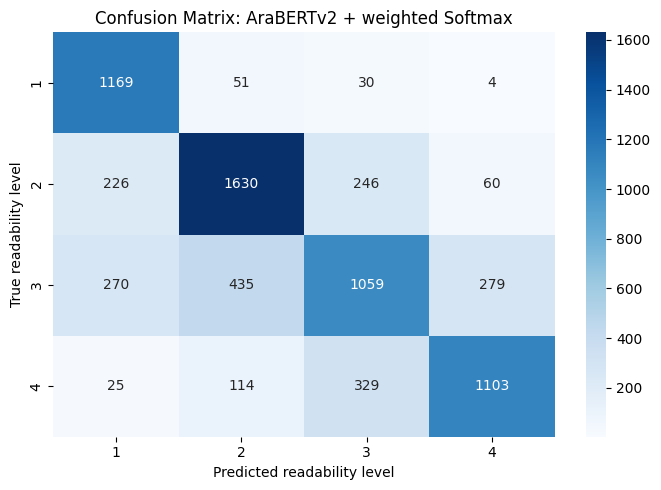

In [29]:
cm = confusion_matrix(test_labels + 1, test_predictions + 1, labels=[1, 2, 3, 4])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted readability level")
plt.ylabel("True readability level")
plt.tight_layout()
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows that most predictions are concentrated along the main diagonal, indicating correct classification across all four levels. The model correctly classified **1,169** Level 1 sentences, **1,630** Level 2 sentences, **1,059** Level 3 sentences, and **1,103** Level 4 sentences.

Level 1 produced the clearest predictions, with only a small number of sentences assigned to distant levels. Level 3 caused the greatest difficulty: **435** Level 3 sentences were classified as Level 2, while **279** were classified as Level 4. Similarly, **329** Level 4 sentences were classified as Level 3. These results indicate that most errors occurred between neighboring readability levels, which is expected because adjacent levels may share similar vocabulary and sentence structures.

However, **270** Level 3 sentences were classified as Level 1, representing the most noticeable distant-level confusion and an area for future model improvement.

## 8. Save the selected model

For the custom CORAL architecture, save its state dictionary together with the encoder name and label mapping. For the standard Softmax model, use the Hugging Face `save_pretrained` format.


In [30]:
SAVE_DIR = "./best_arabic_readability_model"
os.makedirs(SAVE_DIR, exist_ok=True)
tokenizer.save_pretrained(SAVE_DIR)

metadata = {
    "selected_model": best_model_name,
    "base_model": MODEL_NAME,
    "num_labels": NUM_LABELS,
    "max_length": MAX_LENGTH,
    "label_mapping": {str(i): i + 1 for i in range(NUM_LABELS)},
    "validation_results": validation_comparison.to_dict(orient="records"),
    "test_metrics": final_test_metrics,
}

import json
with open(os.path.join(SAVE_DIR, "readability_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

if best_model_name == "AraBERTv2 + CORAL":
    torch.save(best_trainer.model.state_dict(), os.path.join(SAVE_DIR, "coral_model_state.pt"))
else:
    best_trainer.model.save_pretrained(SAVE_DIR)

print("Saved selected model to:", SAVE_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved selected model to: ./best_arabic_readability_model


# Final Findings

The experiments compared two AraBERTv2-based approaches for four-level Arabic readability classification: weighted Softmax classification and ordinal classification. Although the ordinal approach was designed to represent the ordered relationship between readability levels, it did not outperform the conventional weighted Softmax model.

Based on validation QWK, the weighted Softmax model was selected as the final model. On the test set, it achieved **70.57% accuracy**, **70.97% Macro-F1**, and **76.00% QWK**. In addition, **92.84%** of its predictions were correct or within one adjacent readability level.

The model performed best on Level 1 and showed satisfactory performance on Levels 2 and 4. Level 3 remained the most challenging because its linguistic characteristics overlap with both easier and more advanced levels. Overall, the results demonstrate that fine-tuned AraBERTv2 with class-weighted Softmax provides the strongest performance among the evaluated deep learning approaches for the current four-level BAREC classification setting.